
# LASSO

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
import joblib

In [115]:
# 1. Load dataset (standardised features)
df = pd.read_csv('data/df_features_with_label_standardised.csv')

In [116]:
pd.set_option('display.max_columns', None)
df

,date,open,high,low,close,volume,symbol,buy_bitcoin_trend,crypto_crash_trend,bitcoin_price_trend,altcoin_season_trend,sell_crypto_trend,fed_funds,treasury_10y,vix,m2,cpi,real_rate_10y,fear_greed,ret_1d,ret_7d,ret_14d,ret_30d,log_ret,ma_7,ma_14,ma_30,ma_60,ma_ratio_7_30,ma_ratio_30_60,zscore_30,zscore_60,daily_range,atr_7,atr_14,atr_30,volatility_trend,realized_vol_7,realized_vol_30,volume_ma_7,volume_ma_14,volume_ma_30,volume_ratio_7,volume_ratio_30,volume_change_7d,volume_std_30,volume_zscore,price_volume_corr_30,rsi_7,rsi_14,rsi_30,roc_7,roc_14,roc_30,price_position_30,price_position_60,own_trend,own_trend_ma_7,own_trend_ma_14,own_trend_ma_30,own_trend_std_30,own_trend_zscore,own_trend_change_1d,own_trend_change_7d,own_trend_momentum,trend_price_corr_30,trend_volume_corr_30,trend_price_divergence,buy_bitcoin_zscore,crypto_crash_zscore,altcoin_season_zscore,fomo_fear_ratio,fear_greed_ma_7,fear_greed_ma_14,fear_greed_ma_30,fear_greed_std_30,fear_greed_zscore,fear_greed_change_1d,fear_greed_change_7d,fear_greed_change_14d,fear_greed_momentum,extreme_greed,extreme_fear,fear,greed,greed_streak,fear_streak,sentiment_price_corr_30,sentiment_price_divergence,fed_funds_change_1d,fed_funds_change_7d,fed_funds_change_30d,fed_funds_ma_30,treasury_10y_change_1d,treasury_10y_change_7d,treasury_10y_change_30d,yield_spread,yield_spread_change,vix_change_1d,vix_change_7d,vix_regime,m2_growth_30d,m2_growth_60d,m2_growth_90d,cpi_change_30d,real_rate_change,ret_1d_lag_1,ret_7d_lag_1,volume_ratio_30_lag_1,fear_greed_lag_1,rsi_14_lag_1,ret_1d_lag_3,ret_7d_lag_3,volume_ratio_30_lag_3,fear_greed_lag_3,rsi_14_lag_3,ret_1d_lag_7,ret_7d_lag_7,volume_ratio_30_lag_7,fear_greed_lag_7,rsi_14_lag_7,ret_1d_lag_14,ret_7d_lag_14,volume_ratio_30_lag_14,fear_greed_lag_14,rsi_14_lag_14,is_month_start,is_month_end,quarter_2,quarter_3,quarter_4,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,gsadf_map_95,gsadf_map_90,gsadf_map_90_lead,gsadf_map_95_lead,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,2018-05-01,-0.260155,-0.250397,-0.276276,-0.235907,-0.452755,ADA,1.797733,-0.172392,2.070371,-0.108673,-0.217456,-0.331293,0.287083,-0.594840,-10.894823,-5.355385,0.284552,0.393486,-0.032885,-0.121301,-0.145780,-0.249384,-0.006799,-0.272276,-0.270032,-0.257337,-0.258395,-0.161136,-0.207593,-0.140637,-0.172380,0.752922,-0.235264,-0.208228,-0.158462,-0.155493,-0.211154,-0.099154,-0.326314,-0.332249,-0.368494,-0.223632,-0.253538,-0.251559,-0.316198,-0.271637,0.043140,-0.024297,-0.012996,-0.097618,-0.121301,-0.145780,-0.249384,-0.166376,-0.190252,-0.522451,0.127971,0.153802,0.163427,-0.192320,-0.066099,-0.002695,-0.012604,0.058657,-0.116918,0.018578,0.017603,-0.137065,-0.158170,0.003673,-0.150883,-0.063819,-0.059422,-0.080976,-0.209097,0.019973,-0.000393,-0.003105,-0.006321,0.004755,0,0,0,1,-0.448826,-0.507836,-0.044016,-0.009873,-0.024151,-0.063777,-0.130934,-0.117950,0.013521,-0.032969,-0.010322,1.127879,0.013990,-0.037028,-0.046901,0,-0.020127,-1.437813e-02,-0.019028,-0.031175,-0.065154,-0.033035,-0.121743,-0.253530,-0.014233,-0.013295,-0.033284,-0.121228,-0.253617,-0.013420,-0.012778,-0.033675,-0.119641,-0.254249,-0.011387,-0.009225,-0.034557,-0.119803,-0.254354,-0.007863,-0.007989,1,0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,5.000000e-01,-0.866025,0.781831,0.623490
1,2018-05-02,-0.235661,-0.223497,-0.226235,-0.205224,-0.677293,ADA,1.797733,-0.172392,1.941524,-0.108673,-0.217456,-0.331293,0.287083,-0.521474,0.098166,-0.043402,0.273452,0.212138,0.877950,-0.121301,-0.145780,-0.249384,0.884235,-0.272276,-0.270032,-0.257337,-0.258395,-0.161136,-0.207593,-0.140637,-0.172380,0.104766,-0.235264,-0.208228,-0.158462,-0.155493,-0.211154,-0.099154,-0.326314,-0.332249,-0.368494,-0.223632,-0.253538,-0.251559,-0.316198,-0.271637,0.043140,-0.024297,-0.012996,-0.097618,-0.121301,-0.145780,-0.249384,-0.166376,-0.190252,-0.644011,0.127971,0.153802,0.163427,-0.192320,-0.066099,-0.323047,-0.012604,0.058657,-0.116918,0.018578,0.017603,-0.137065,-0.158170,0.003673,-0.15

In [117]:
# 2. Train-test split
train_df = df[df['date'] < '2024-01-01']
test_df = df[df['date'] >= '2024-01-01']

In [118]:
train_df[['symbol', 'gsadf_map_90']].value_counts()

symbol  gsadf_map_90
BTC     0               1696
BNB     0               1655
ADA     0               1624
ETH     0               1606
DOGE    0               1343
SOL     0                916
ETH     1                307
ADA     1                289
BTC     1                276
BNB     1                244
DOGE    1                183
SOL     1                178
BNB     2                172
ADA     2                158
ETH     2                158
SOL     2                144
DOGE    2                115
BTC     2                 99
Name: count, dtype: int64

In [119]:
test_df[['symbol', 'gsadf_map_90_lead']].value_counts()

symbol  gsadf_map_90_lead
ADA     0                    319
ETH     0                    312
DOGE    0                    289
BNB     0                    246
SOL     0                    222
BTC     0                    208
        1                    135
SOL     1                    111
BNB     1                    102
DOGE    1                     76
ETH     1                     49
ADA     1                     47
SOL     2                     33
BTC     2                     23
BNB     2                     18
ETH     2                      5
DOGE    2                      1
Name: count, dtype: int64

### Model for all coins

In [147]:
# 3. Train multinomial logistic regression with Lasso penalty
all_cols = train_df.columns.tolist()
not_x = ['symbol', 'date', 'gsadf_map_95', 'gsadf_map_90', 'gsadf_map_90_lead', 'gsadf_map_95_lead']
x_cols = [col for col in all_cols if col not in not_x]

X_train = train_df[x_cols]
y_train = train_df['gsadf_map_90_lead'].astype(int)

clf = LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        multi_class='multinomial',
        class_weight='balanced',
        cv=5,
        max_iter=10000,
        random_state=42,
        n_jobs=-1 
    )
    
clf.fit(X_train, y_train)

joblib.dump(clf, f'models/lasso_all_coins.pkl')

/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


['models/lasso_all_coins.pkl']

In [148]:
# 4. Evaluate model coefficients
weights_df = pd.DataFrame(
    clf.coef_, 
    columns=x_cols, 
    index=[f'Class_{c}_Weight' for c in clf.classes_]
).T

# Add an "Absolute Importance" column to help with sorting
# This shows which features had the most impact overall across all classes
weights_df['Total_Absolute_Impact'] = weights_df.abs().sum(axis=1)

total_features = len(weights_df)
eliminated_features = weights_df[weights_df['Total_Absolute_Impact'] == 0]
num_eliminated = len(eliminated_features)
num_survivors = total_features - num_eliminated

print(f"--- Feature Selection Summary ---")
print(f"Total Features analyzed: {total_features}")
print(f"Eliminated (Zero Weight): {num_eliminated} ({num_eliminated/total_features:.1%})")
print(eliminated_features.index.tolist())
print("\n")

# Sort by impact (Highest at the top, 0s at the bottom)
weights_df = weights_df.sort_values(by='Total_Absolute_Impact', ascending=False)

print("--- Top 15 Feature Weight Leaderboard ---")
print(weights_df.head(15))

--- Feature Selection Summary ---
Total Features analyzed: 140
Eliminated (Zero Weight): 51 (36.4%)
['open', 'low', 'close', 'bitcoin_price_trend', 'altcoin_season_trend', 'fed_funds', 'cpi', 'real_rate_10y', 'fear_greed', 'ret_7d', 'ret_14d', 'log_ret', 'ma_7', 'ma_14', 'ma_60', 'atr_14', 'realized_vol_7', 'volume_ma_14', 'volume_ratio_7', 'rsi_14', 'roc_7', 'roc_14', 'price_position_60', 'own_trend_ma_14', 'own_trend_change_7d', 'altcoin_season_zscore', 'fear_greed_change_1d', 'fear_greed_change_7d', 'fear_greed_change_14d', 'extreme_greed', 'greed_streak', 'vix_change_1d', 'm2_growth_30d', 'm2_growth_90d', 'cpi_change_30d', 'real_rate_change', 'ret_7d_lag_1', 'fear_greed_lag_1', 'rsi_14_lag_1', 'ret_7d_lag_3', 'rsi_14_lag_3', 'ret_1d_lag_7', 'ret_7d_lag_7', 'rsi_14_lag_7', 'fear_greed_lag_14', 'is_month_start', 'is_month_end', 'year_2023', 'year_2024', 'year_2025', 'day_of_week_sin']


--- Top 15 Feature Weight Leaderboard ---
                      Class_0_Weight  Class_1_Weight  Cl

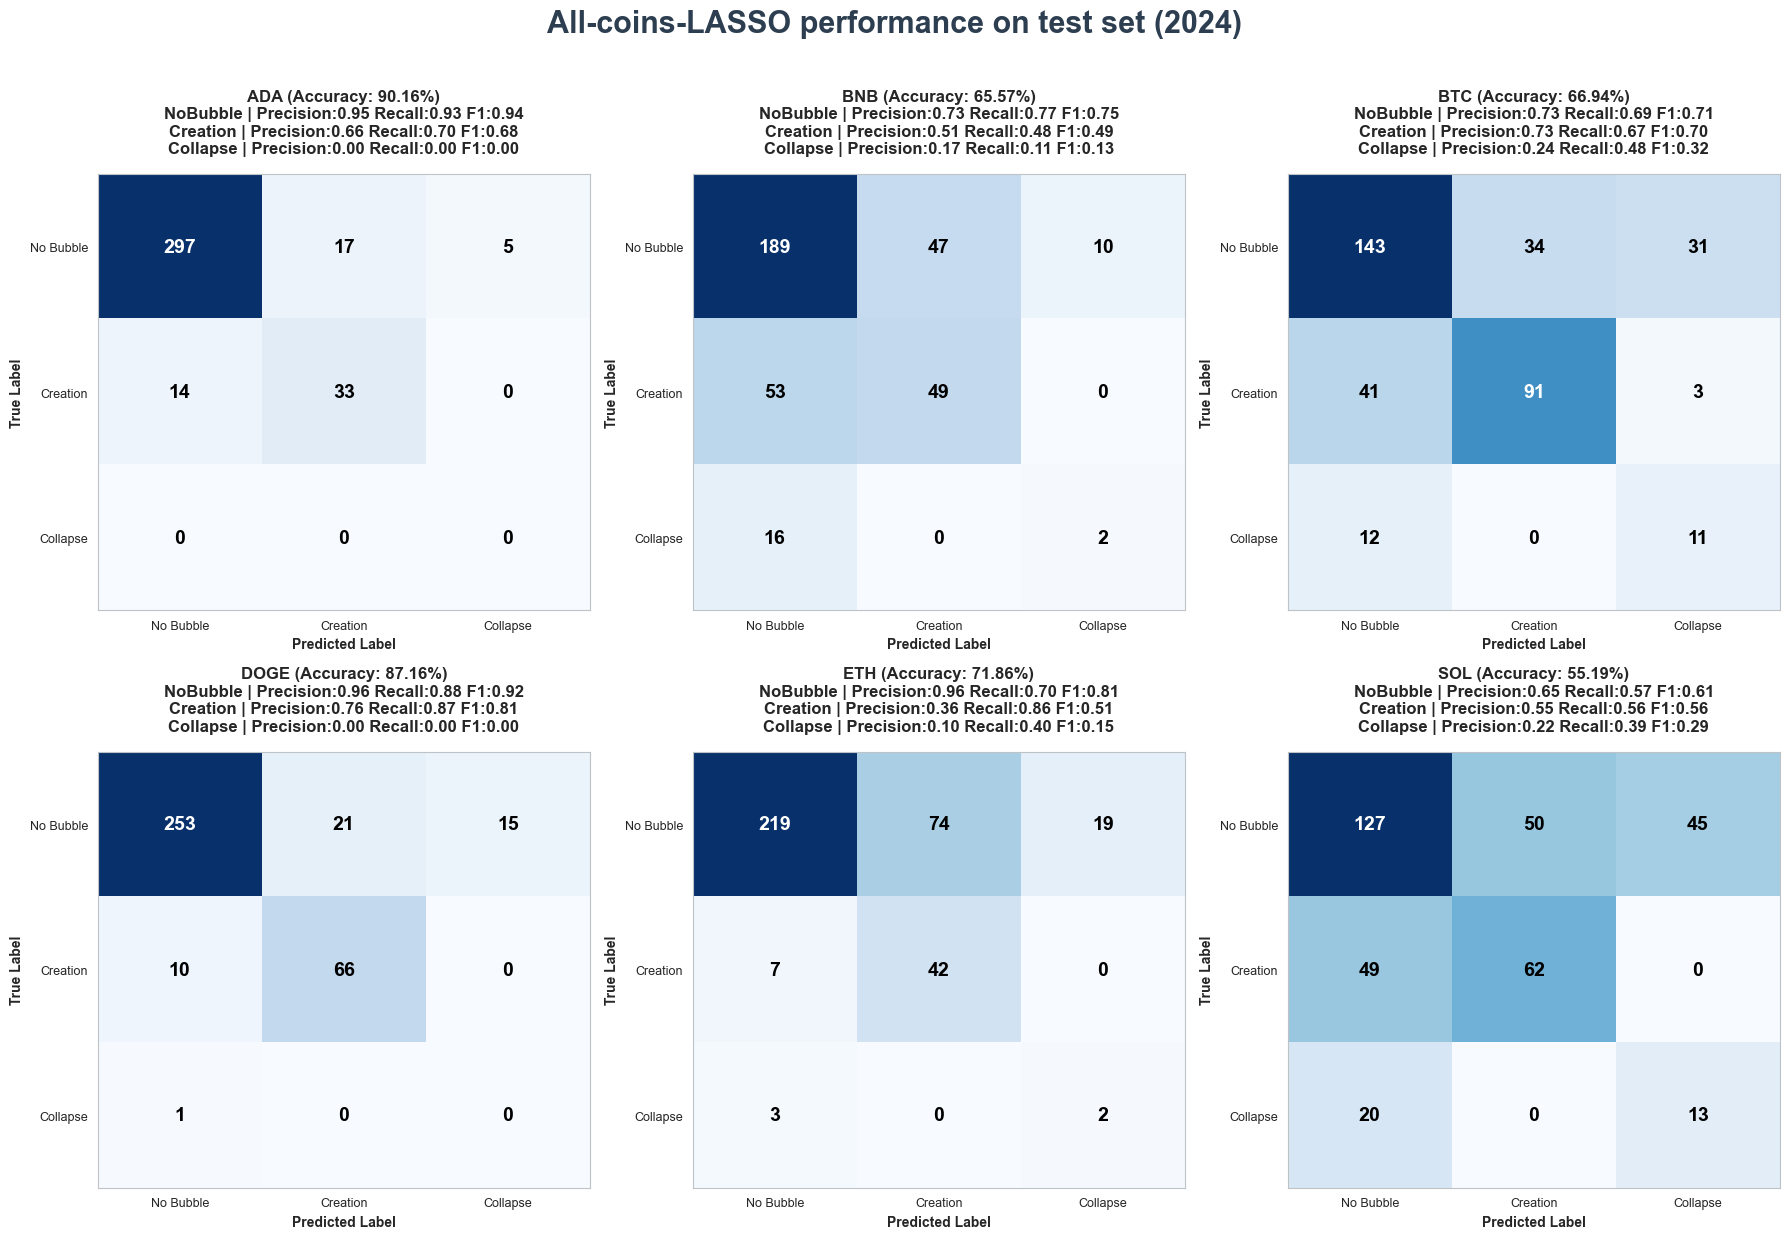

In [149]:
# 11. Test model on test set and show confusion matrix for each coin
coins = test_df['symbol'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 13))
axes = axes.flatten()

labels = [0, 1, 2]
target_names = ['No Bubble', 'Creation', 'Collapse']

for i, coin in enumerate(coins):
    ax = axes[i]
    
    # Filter test data for the specific coin
    coin_test = test_df[test_df['symbol'] == coin].copy()
    
    # Pre-calculate true vs predicted
    y_true = coin_test['gsadf_map_90_lead'].astype(int)
    y_pred = clf.predict(coin_test[x_cols]).astype(int)
    
    # Create Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Calculate Recalls
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    
    # Plotting the Matrix Heatmap
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    ax.grid(False) # Ensure internal gridlines are off
    
    # Add numbers to the boxes
    for row in range(len(labels)):
        for col in range(len(labels)):
            ax.text(col, row, format(cm[row, col], 'd'),
                    ha="center", va="center",
                    color="white" if cm[row, col] > cm.max()/2 else "black",
                    fontsize=14, fontweight='bold')

    # Titles and Recalls
    title_str = (f"{coin} (Accuracy: {acc:.2%})\n"
                 f"NoBubble | Precision:{precision[0]:.2f} Recall:{recall[0]:.2f} F1:{f1[0]:.2f}\n"
                 f"Creation | Precision:{precision[1]:.2f} Recall:{recall[1]:.2f} F1:{f1[1]:.2f}\n"
                 f"Collapse | Precision:{precision[2]:.2f} Recall:{recall[2]:.2f} F1:{f1[2]:.2f}")
    ax.set_title(title_str, fontsize=12, fontweight='bold', pad=15)
    
    # --- ADDED X AND Y LABELS ---
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    
    # Tick settings
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(target_names, fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    
    # Clean up axis spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#bdc3c7')

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.suptitle("All-coins-LASSO performance on test set (2024)", 
             fontsize=22, fontweight='bold', y=0.98, color='#2c3e50')

plt.savefig('data/outputs/All_coins_LASSO_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Coin-specific models (x6)

In [ ]:
# 1. Train 6 coin-specific models
model_zoo = {}

for coin in coins:
    print(f"Training LASSO for: {coin}...")

    coin_train = train_df[train_df['symbol'] == coin].dropna(subset=x_cols + ['gsadf_map_90_lead'])
        
    X_c = coin_train[x_cols]
    y_c = coin_train['gsadf_map_90_lead'].astype(int)
    
    model = LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        multi_class='multinomial',
        class_weight='balanced',
        cv=5,
        max_iter=10000,
        random_state=42,
        n_jobs=-1 
    )
    
    # Fit
    model.fit(X_c, y_c)
    
    # Save to Memory
    model_zoo[coin] = model
    
    # Save to Disk
    joblib.dump(model, f'models/lasso_{coin}.pkl')

print(f"\nTraining Complete. {len(model_zoo)} models are now in 'model_zoo' and disk.")

Training LASSO for: ADA...


/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training LASSO for: BNB...


/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training LASSO for: BTC...


...

Training LASSO for: ETH...


/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training LASSO for: SOL...


/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training Complete. 6 models are now in 'model_zoo' and disk.


In [ ]:
# 2. Analyse model weights
def analyze_lasso_weights(model, x_cols, symbol):
    weights_df = pd.DataFrame(
        model.coef_, 
        columns=x_cols, 
        index=[f'Class_{c}' for c in model.classes_]
    ).T
    
    # 2. Calculate Importance
    weights_df['Total_Abs_Impact'] = weights_df.abs().sum(axis=1)
    weights_df = weights_df.sort_values(by='Total_Abs_Impact', ascending=False)
    
    # 3. Stats
    total = len(weights_df)
    survivors = (weights_df['Total_Abs_Impact'] > 0).sum()
    eliminated = total - survivors
    
    print(f"--- [{symbol}] Feature Selection Summary ---")
    print(f"Kept: {survivors} | Eliminated: {eliminated} ({eliminated/total:.1%})")
    
    return weights_df

In [139]:
for coin in coins:
    weights = analyze_lasso_weights(model_zoo[coin], x_cols, coin)
    print(weights.head(10))
    print("\n")

--- [ADA] Feature Selection Summary ---
Kept: 13 | Eliminated: 127 (90.7%)
                    Class_0   Class_1   Class_2  Total_Abs_Impact
ma_30             -0.718760  0.000000  0.000000          0.718760
ma_60              0.000000  0.000000  0.687105          0.687105
zscore_60          0.000000  0.285291  0.000000          0.285291
price_position_60  0.000000  0.284123  0.000000          0.284123
ma_ratio_30_60     0.000000  0.250009  0.000000          0.250009
ret_30d            0.000000  0.195465  0.000000          0.195465
roc_30             0.000000  0.195465  0.000000          0.195465
volume_ma_14       0.000000  0.130923  0.000000          0.130923
volume_ma_30      -0.091884  0.000000  0.000000          0.091884
volume_std_30     -0.087431  0.000000  0.000000          0.087431


--- [BNB] Feature Selection Summary ---
Kept: 39 | Eliminated: 101 (72.1%)
                     Class_0   Class_1   Class_2  Total_Abs_Impact
year_2021          -2.262582  0.000000  0.000000       

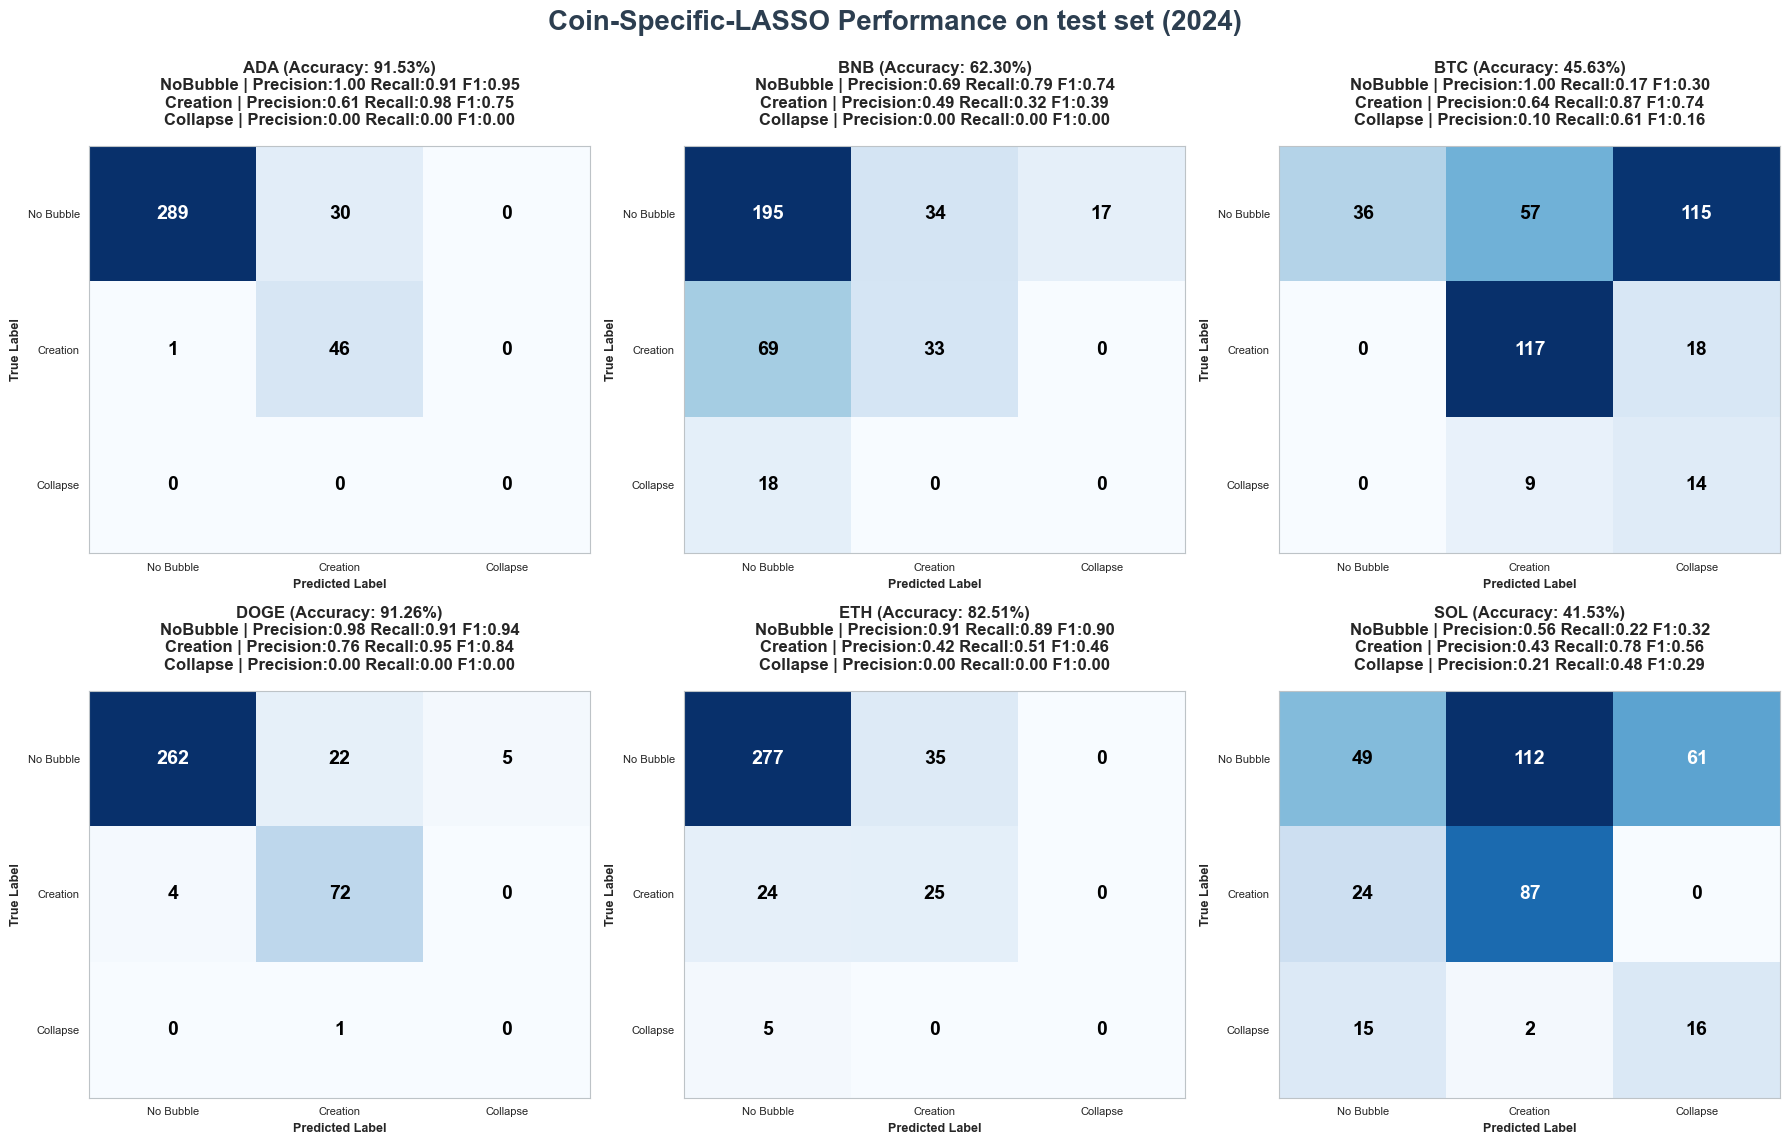

In [146]:
coins = test_df['symbol'].unique()
n_coins = len(coins)
cols = 3
rows = (n_coins // cols) + (1 if n_coins % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

labels = [0, 1, 2]
target_names = ['No Bubble', 'Creation', 'Collapse']

for i, coin in enumerate(coins):
    ax = axes[i]

    coin_test = test_df[test_df['symbol'] == coin].copy()

    X_test_coin = coin_test[x_cols].astype(float)
    y_true = coin_test['gsadf_map_90_lead'].astype(int)
    
    expert_model = model_zoo[coin]
    y_pred = expert_model.predict(X_test_coin).astype(int)
    
    # Calculate Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    
    # Create Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Plotting the Matrix Heatmap
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.grid(False) 
    
    # Add numbers to the boxes
    for row in range(len(labels)):
        for col in range(len(labels)):
            ax.text(col, row, format(cm[row, col], 'd'),
                    ha="center", va="center",
                    color="white" if cm[row, col] > cm.max()/2 else "black",
                    fontsize=14, fontweight='bold')

    # Titles and Metrics
    title_str = (f"{coin} (Accuracy: {acc:.2%})\n"
                 f"NoBubble | Precision:{precision[0]:.2f} Recall:{recall[0]:.2f} F1:{f1[0]:.2f}\n"
                 f"Creation | Precision:{precision[1]:.2f} Recall:{recall[1]:.2f} F1:{f1[1]:.2f}\n"
                 f"Collapse | Precision:{precision[2]:.2f} Recall:{recall[2]:.2f} F1:{f1[2]:.2f}")
    ax.set_title(title_str, fontsize=12, fontweight='bold', pad=15)
    
    # Axis Labels & Ticks
    ax.set_xlabel('Predicted Label', fontsize=9, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(target_names, fontsize=8)
    ax.set_yticklabels(target_names, fontsize=8)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#bdc3c7')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.suptitle("Coin-Specific-LASSO Performance on test set (2024)", 
             fontsize=20, fontweight='bold', y=0.98, color='#2c3e50')

plt.savefig('data/outputs/Coin_Specific_LASSO_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()